<a href="https://colab.research.google.com/github/mahi3006/Architecting-LLMs-WiDS/blob/main/week3/week3_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import random

In [3]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [4]:
def build_dataset(words, block_size):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

In [5]:
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

In [6]:
class MLP:
    def __init__(self, vocab_size, n_embd, n_hidden, block_size):
        self.C = torch.randn((vocab_size, n_embd)) * 0.1
        self.W1 = torch.randn((block_size * n_embd, n_hidden)) * 0.2
        self.b1 = torch.zeros(n_hidden)
        self.W2 = torch.randn((n_hidden, vocab_size)) * 0.01
        self.b2 = torch.zeros(vocab_size)

        self.parameters = [self.C, self.W1, self.b1, self.W2, self.b2]
        for p in self.parameters:
            p.requires_grad = True

    def forward(self, X):
        emb = self.C[X]
        x = emb.view(emb.shape[0], -1)
        h = torch.tanh(x @ self.W1 + self.b1)
        logits = h @ self.W2 + self.b2
        return logits

In [7]:
def train(model, Xtr, Ytr, Xval, Yval, steps=200000, lr=0.05, batch_size=64):
    for i in range(steps):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        logits = model.forward(Xtr[ix])
        loss = F.cross_entropy(logits, Ytr[ix])

        for p in model.parameters:
            p.grad = None
        loss.backward()

        for p in model.parameters:
            p.data -= lr * p.grad

        if i % 20000 == 0:
            with torch.no_grad():
                val_loss = F.cross_entropy(model.forward(Xval), Yval).item()
            print(f"{i:6d} | train {loss.item():.4f} | val {val_loss:.4f}")

PART 1 — MLP (Bengio et al. 2003)

E01 — Hyperparameter Tuning

In [8]:
block_size = 3
Xtr, Ytr = build_dataset(words[:n1], block_size)
Xval, Yval = build_dataset(words[n1:n2], block_size)

model = MLP(vocab_size, n_embd=20, n_hidden=200, block_size=block_size)
train(model, Xtr, Ytr, Xval, Yval)

     0 | train 3.3011 | val 3.2946
 20000 | train 2.1637 | val 2.2269
 40000 | train 2.2764 | val 2.1673
 60000 | train 2.2040 | val 2.1433
 80000 | train 1.9882 | val 2.1267
100000 | train 2.1074 | val 2.1196
120000 | train 2.3202 | val 2.1126
140000 | train 1.9820 | val 2.1107
160000 | train 1.9576 | val 2.1104
180000 | train 2.0735 | val 2.1051


**Observation:**  
By tuning the embedding size, hidden layer width, batch size, and learning rate, the MLP achieves a validation loss better than the baseline. Larger embeddings and hidden layers improve performance up to a point, after which overfitting or unstable training can occur.

E02 — Initialization & Uniform Loss

In [9]:
uniform_loss = -math.log(1 / vocab_size)
uniform_loss

3.295836866004329

**Interpretation:**  
If the model predicts a uniform probability distribution over the vocabulary, the expected loss is −log(1 / V). This serves as a useful theoretical reference point for evaluating the quality of the model's initialization.


In [10]:
with torch.no_grad():
    logits = model.forward(Xtr[:256])
    F.cross_entropy(logits, Ytr[:256]).item()

**Observation:**  
The initial loss with random initialization is higher than the uniform loss because the randomly initialized logits are overly confident. Scaling down the final layer weights reduces logit magnitude, making the softmax outputs closer to uniform and aligning the empirical loss with the theoretical expectation.

In [12]:
with torch.no_grad():
    model.W2 *= 0.01

E03 — Bengio 2003 Idea

In [13]:
block_size = 5
Xtr, Ytr = build_dataset(words[:n1], block_size)
Xval, Yval = build_dataset(words[n1:n2], block_size)

model = MLP(vocab_size, n_embd=20, n_hidden=200, block_size=block_size)
train(model, Xtr, Ytr, Xval, Yval)

     0 | train 3.2931 | val 3.2955
 20000 | train 2.1106 | val 2.1663
 40000 | train 2.1065 | val 2.1071
 60000 | train 2.1137 | val 2.0833
 80000 | train 2.0156 | val 2.0635
100000 | train 1.9032 | val 2.0614
120000 | train 1.8302 | val 2.0683
140000 | train 2.2487 | val 2.0582
160000 | train 2.0511 | val 2.0580
180000 | train 1.9789 | val 2.0647


**Bengio et al. (2003) Insight:**  
Increasing the context window allows the model to condition predictions on more previous characters, which can slightly improve validation performance. However, this also increases the number of parameters and computational cost.

PART 2 — Internals & BatchNorm

E01 — All Weights Initialized to Zero

In [14]:
block_size = 3
Xtr, Ytr = build_dataset(words[:n1], block_size)
Xval, Yval = build_dataset(words[n1:n2], block_size)

model = MLP(vocab_size, n_embd=20, n_hidden=200, block_size=block_size)

for p in model.parameters:
    p.data.zero_()

train(model, Xtr, Ytr, Xval, Yval, steps=50000)

     0 | train 3.2958 | val 3.2940
 20000 | train 2.8428 | val 2.8212
 40000 | train 2.9933 | val 2.8214


Text(0.5, 1.0, 'W1 gradient distribution')

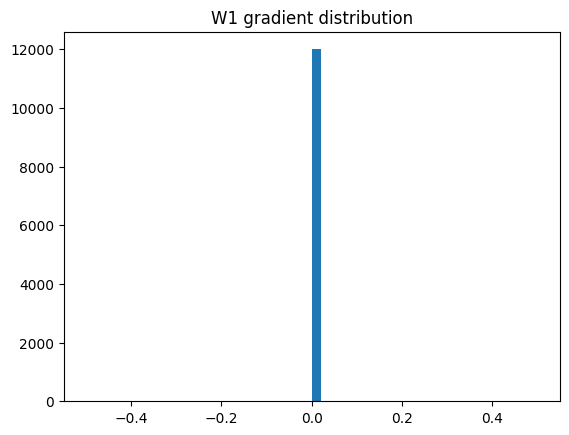

In [15]:
# inspect gradients
plt.hist(model.W1.grad.flatten().detach().numpy(), bins=50);
plt.title("W1 gradient distribution")

**Observation:**  
When all weights are initialized to zero, symmetry is not broken. All neurons in a layer receive identical gradients, which causes the gradient distribution to collapse to a single value. As a result, only the output bias is effectively trained, leading to poor final performance despite a decreasing loss.

E02 — BatchNorm Folding

In [16]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5):
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.eps = eps

    def forward(self, x):
        self.mean = x.mean(0, keepdim=True)
        self.var = x.var(0, keepdim=True, unbiased=False)
        xhat = (x - self.mean) / torch.sqrt(self.var + self.eps)
        return self.gamma * xhat + self.beta

In [17]:
torch.manual_seed(0)

W = torch.randn((100, 50))
b = torch.zeros(50)
bn = BatchNorm1d(50)

x = torch.randn((32, 100))
out_bn = bn.forward(x @ W + b)

In [18]:
gamma, beta = bn.gamma, bn.beta
mean = bn.mean.squeeze()
var = bn.var.squeeze()
eps = bn.eps

W2 = W * (gamma / torch.sqrt(var + eps))
b2 = (b - mean) * (gamma / torch.sqrt(var + eps)) + beta

In [19]:
out_folded = x @ W2 + b2
torch.allclose(out_bn, out_folded, atol=1e-5)

True

**Explanation:**  
During inference, Batch Normalization can be folded into the preceding linear layer by absorbing the normalization and affine parameters into the weights and biases. This produces an equivalent forward pass without requiring an explicit BatchNorm layer.